In [1]:
pip install opencv-python

In [2]:
pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 15.8 MB/s eta 0:00:00


In [13]:
import cv2
import easyocr
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import re
import pandas as pd
import os



In [4]:
# Initialize EasyOCR reader ONCE
reader = easyocr.Reader(['en'], gpu=False)

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [7]:
def preprocess_plate_for_ocr(roi):
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    # zoom plate for OCR
    gray = cv2.resize(gray, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)

    # improve contrast
    clahe = cv2.createCLAHE(2.0, (8,8))
    gray = clahe.apply(gray)

    # sharpen characters
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    sharp = cv2.addWeighted(gray, 1.5, blur, -0.5, 0)

    return sharp


In [8]:
def read_plate_easyocr(roi):
    processed = preprocess_plate_for_ocr(roi)

    results = reader.readtext(
        processed,
        detail=1,
        paragraph=False,
        allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789 "
    )

    best_text = ""
    best_conf = 0

    for _, text, conf in results:
        text = text.upper()
        text = re.sub(r'[^A-Z0-9 ]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()

        # EU plates vary → keep flexible length
        if 5 <= len(text.replace(" ", "")) <= 10 and conf > best_conf:
            best_text = text
            best_conf = conf

    return best_text, best_conf


In [11]:
import re

def normalize_and_validate_plate(text):
    """
    Accepts:
    1) 8 chars with exactly 1 space at index 4  (AB12 345)
    2) 7 alphanumeric chars, no space           (AB12345)
    Returns normalized plate string or None
    """
    if not text:
        return None

    # keep only A-Z, 0-9, space
    text = text.upper()
    text = re.sub(r'[^A-Z0-9 ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Case 1: 8 chars with space at index 4
    if len(text) == 8 and text[4] == ' ':
        left = text[:4]
        right = text[5:]
        if left.isalnum() and right.isalnum():
            return text

    # Case 2: 7 chars, no space
    if len(text) == 7 and text.isalnum():
        return text

    return None


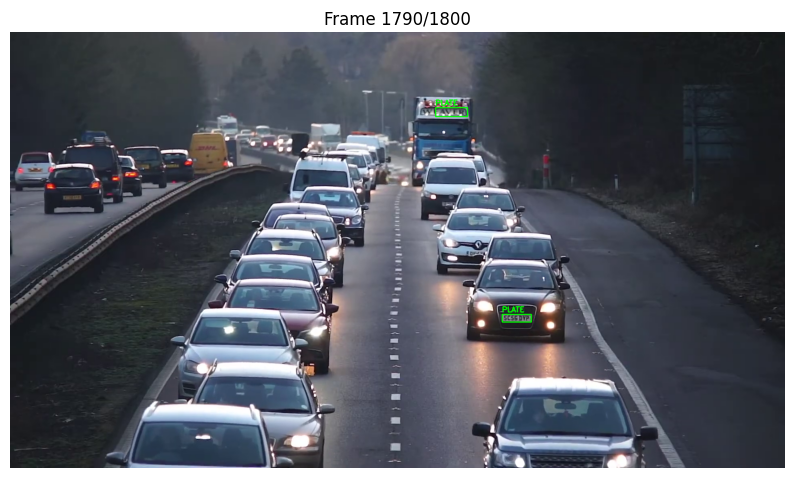

Frame 1791: Plate=SCS6 DLP, Conf=0.14
Frame 1792: Plate=SCSG DLP, Conf=0.15
Frame 1794: Plate=SCS6 DLP, Conf=0.26
Frame 1795: Plate=SCS6 DYP, Conf=0.23
Frame 1796: Plate=SCSB DYP, Conf=0.15
✅ Processing complete
✅ Output saved as plate_full_output.mp4
✅ Frames processed: 1800
⏱ Expected duration: 60.00 seconds
✅ Excel saved: detected_plates.xlsx
✅ High-confidence plate images saved in: high_confidence_plates
✅ Unique plates: 280


In [16]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# -----------------------------
# CONFIG
# -----------------------------
VIDEO_PATH = "License Plate Detection Test.mp4"
OUTPUT_PATH = "plate_full_output.mp4"
PREVIEW_INTERVAL = 10     # show 1 frame every 10 frames in Jupyter

# -----------------------------
# OPEN VIDEO
# -----------------------------
cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise RuntimeError("❌ Cannot open video")

fps = cap.get(cv2.CAP_PROP_FPS)
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"✅ Video opened")
print(f"FPS: {fps}")
print(f"Resolution: {W}x{H}")
print(f"Total frames: {total_frames}")

# -----------------------------
# VIDEO WRITER (CRITICAL)
# -----------------------------
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (W, H))

# -----------------------------
# HELPER FUNCTIONS
# -----------------------------
def is_white_plate_saturation(roi):
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    mean_sat = hsv[:, :, 1].mean()
    return mean_sat < 60

def has_text_edges(roi):
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 5))
    vertical = cv2.morphologyEx(edges, cv2.MORPH_OPEN, kernel)
    density = cv2.countNonZero(vertical) / (roi.shape[0] * roi.shape[1])
    return density > 0.02

# Excel data
excel_rows = []

# avoid saving same plate image many times
saved_plate_images = set()

# directory for high-confidence plate images
HIGH_CONF_DIR = "high_confidence_plates"
os.makedirs(HIGH_CONF_DIR, exist_ok=True)

# thresholds
HIGH_CONF_THRESHOLD = 0.5   # image saved only if OCR very confident


# -----------------------------
# PROCESS ENTIRE VIDEO
# -----------------------------
frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break   # ✅ end of video ONLY

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 40, 120)

    contours, _ = cv2.findContours(
        edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = w * h
        ratio = w / float(h)

        # ---- SIZE FILTER ----
        if area < 1200 or area > 10000:
            continue

        # ---- SHAPE FILTER ----
        if not (2.5 < ratio < 5.5):
            continue
        if h > 0.12 * H:
            continue

        roi = frame[y:y+h, x:x+w]
        if roi.size == 0:
            continue

        # ---- COLOR FILTER ----
        if not is_white_plate_saturation(roi):
            continue

        # ---- TEXTURE FILTER ----
        if not has_text_edges(roi):
            continue


        # ---- FINAL DRAW ----
        plate_text, conf = read_plate_easyocr(roi)

      # ---- DRAW BOX ON VIDEO ----
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

        label = "PLATE"

        validated_plate = normalize_and_validate_plate(plate_text)

        if validated_plate:
            label = validated_plate
            key = validated_plate.replace(" ", "")

            # print in notebook
            print(f"Frame {frame_count}: Plate={validated_plate}, Conf={conf:.2f}")

            # save to excel rows
            excel_rows.append({
                "Plate": validated_plate,
                "Confidence": round(conf, 3),
                "Frame": frame_count
            })

            # save high-confidence plate image ONCE
            if conf >= HIGH_CONF_THRESHOLD and key not in saved_plate_images:
                plate_img = frame[y:y+h, x:x+w]
                img_name = f"{validated_plate.replace(' ', '_')}_frame_{frame_count}.png"
                cv2.imwrite(os.path.join(HIGH_CONF_DIR, img_name), plate_img)
                saved_plate_images.add(key)

        cv2.putText(
            frame, label,
            (x, y - 6),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6, (0, 255, 0), 2
        )




    # ✅ WRITE EVERY FRAME (VERY IMPORTANT)
    out.write(frame)

    # -----------------------------
    # JUPYTER PREVIEW (SAFE)
    # -----------------------------
    if frame_count % PREVIEW_INTERVAL == 0:
        clear_output(wait=True)
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title(f"Frame {frame_count}/{total_frames}")
        plt.axis("off")
        display(plt.gcf())
        plt.close()

    frame_count += 1

# -----------------------------
# CLEANUP
# -----------------------------
cap.release()
out.release()

print("✅ Processing complete")
print(f"✅ Output saved as {OUTPUT_PATH}")
print(f"✅ Frames processed: {frame_count}")
print(f"⏱ Expected duration: {frame_count / fps:.2f} seconds")

# create dataframe
df = pd.DataFrame(excel_rows)

# optional: drop duplicates keeping highest confidence
df = df.sort_values("Confidence", ascending=False)
df = df.drop_duplicates(subset=["Plate"], keep="first")

# save to excel
excel_path = "detected_plates.xlsx"
df.to_excel(excel_path, index=False)

print("✅ Excel saved:", excel_path)
print("✅ High-confidence plate images saved in:", HIGH_CONF_DIR)
print("✅ Unique plates:", df.shape[0])



In [19]:
!zip -r high_confidence_plates.zip high_confidence_plates


  adding: high_confidence_plates/ (stored 0%)
  adding: high_confidence_plates/0G65_USJ_frame_454.png (deflated 2%)
  adding: high_confidence_plates/BPBELYH_frame_1161.png (deflated 4%)
  adding: high_confidence_plates/LG65_ZFX_frame_1231.png (deflated 0%)
  adding: high_confidence_plates/BC6S_USJ_frame_406.png (deflated 1%)
  adding: high_confidence_plates/LLGIPZS_frame_1343.png (deflated 2%)
  adding: high_confidence_plates/FJIAZHY_frame_274.png (deflated 1%)
  adding: high_confidence_plates/DAOZCLX_frame_913.png (deflated 2%)
  adding: high_confidence_plates/LLEIPZS_frame_1341.png (deflated 2%)
  adding: high_confidence_plates/KH06_KSU_frame_722.png (deflated 5%)
  adding: high_confidence_plates/BP63LYH_frame_1180.png (deflated 5%)
  adding: high_confidence_plates/LWIS_ZZC_frame_776.png (deflated 1%)
  adding: high_confidence_plates/0G65_ZFX_frame_1306.png (deflated 2%)
  adding: high_confidence_plates/BG6S_U5J_frame_422.png (deflated 0%)
  adding: high_confidence_plates/1G65_ZFX_fr

In [20]:
from google.colab import files
files.download("high_confidence_plates.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>